In [2]:
import xarray as xr
import pandas as pd

In [1]:
#读取文件夹信息
import os
path=os.listdir('ClimData/petPM')
#path.remove('.ipynb_checkpoints')

In [3]:
print(path)

['2018year', '2019year', '2020year', '2021year', '2022year']


In [4]:
path_time='ChinaMet_001deg_petPM_2018_01.nc'

In [5]:
path_time.split('_')[-2]

'2018'

In [6]:
# ===================== 配置参数 =====================
nc_file_path = "ClimData/petPM/2018year/ChinaMet_001deg_petPM_2018_01.nc"    # 格点.nc文件路径
csv_output_path = "ToCSVResult/meteor_data.csv"  # 输出CSV路径
# 贵阳市经纬度范围为东经106° 07′ ～ 107°17 ′，纬度范围为北纬26°11′～ 27°22′（106.12°E~107.28°E，26.18°N~27.37°N）
guiyang_lon_range = (106.12, 107.28)
guiyang_lat_range = (26.18, 27.37)

In [7]:
# ===================== 读取并筛选贵阳市格点 =====================
ds = xr.open_dataset(nc_file_path)
# 筛选贵阳市范围内的格点（按经纬度切片）
ds_guiyang = ds.sel(
    lon=slice(*guiyang_lon_range),
    lat=slice(*guiyang_lat_range)
)

In [8]:
ds_guiyang

<xarray.Dataset> Size: 57kB
Dimensions:  (lat: 119, lon: 116)
Coordinates:
  * lat      (lat) float64 952B 26.19 26.2 26.21 26.22 ... 27.35 27.36 27.37
  * lon      (lon) float64 928B 106.1 106.1 106.1 106.2 ... 107.3 107.3 107.3
Data variables:
    petPM    (lat, lon) float32 55kB ...
Attributes:
    Title:        ChinaMet: A new multisource merged and multi-variable meteo...
    Data Period:  1980-2022
    Contact:      Dr. Ling Zhang, Email: zhanglingky@lzb.ac.cn, Northwest Ins...

In [9]:
df_guiyang=ds_guiyang.to_dataframe().reset_index()

In [10]:
df_guiyang

,lat,lon,petPM
0,26.186261,106.122457,36.923092
1,26.186261,106.132457,36.838314
2,26.186261,106.142457,36.623444
3,26.186261,106.152457,36.499481
4,26.186261,106.162457,36.182579
...,...,...,...
13799,27.366261,107.232457,26.124538
13800,27.366261,107.242457,26.108131
13801,27.366261,107.252457,26.084719
13802,27.366261,107.262457,26.613928


可视化数据

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import warnings
warnings.filterwarnings("ignore")

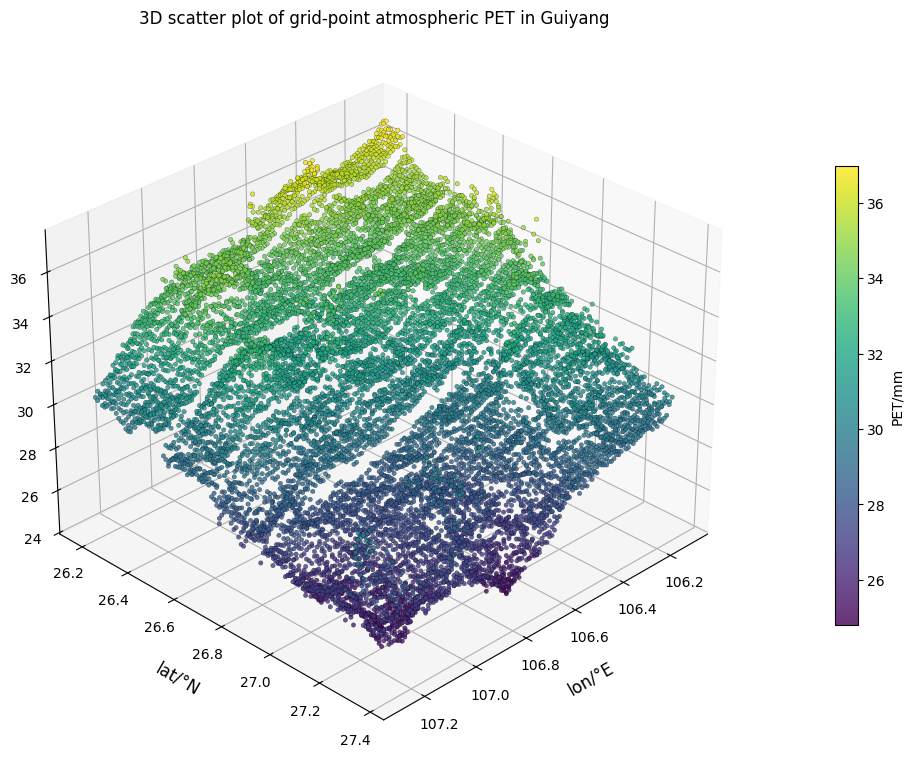

In [13]:
#整理数据
lat=df_guiyang["lat"].values
lon=df_guiyang["lon"].values
pres=df_guiyang["petPM"].values
# 生成规则网格（用于3D曲面/网格图）
lon_grid,lat_grid=np.meshgrid(np.linspace(lon.min(), lon.max(), 50),np.linspace(lat.min(), lat.max(), 50))
#压力数据插值
pres_grid = griddata(points=(lon, lat),values=pres, xi=(lon_grid, lat_grid), method="linear")
#绘制3D散点
fig1 = plt.figure(figsize=(10, 8))
ax1 = fig1.add_subplot(111, projection="3d")
ax1.set_title("3D scatter plot of grid-point atmospheric PET in Guiyang")
scatter=ax1.scatter(lon,lat,pres,c=pres,cmap="viridis",s=10,alpha=0.8,edgecolors="k",linewidths=0.2)
ax1.set_xlabel("lon/°E", fontsize=12, labelpad=10)
ax1.set_ylabel("lat/°N", fontsize=12, labelpad=10)
ax1.set_zlabel("PET/mm", fontsize=12, labelpad=10)
cbar1 = fig1.colorbar(scatter, ax=ax1, shrink=0.6, pad=0.1)
cbar1.set_label("PET/mm", fontsize=10)
ax1.view_init(elev=30, azim=45)
plt.tight_layout()
plt.show()

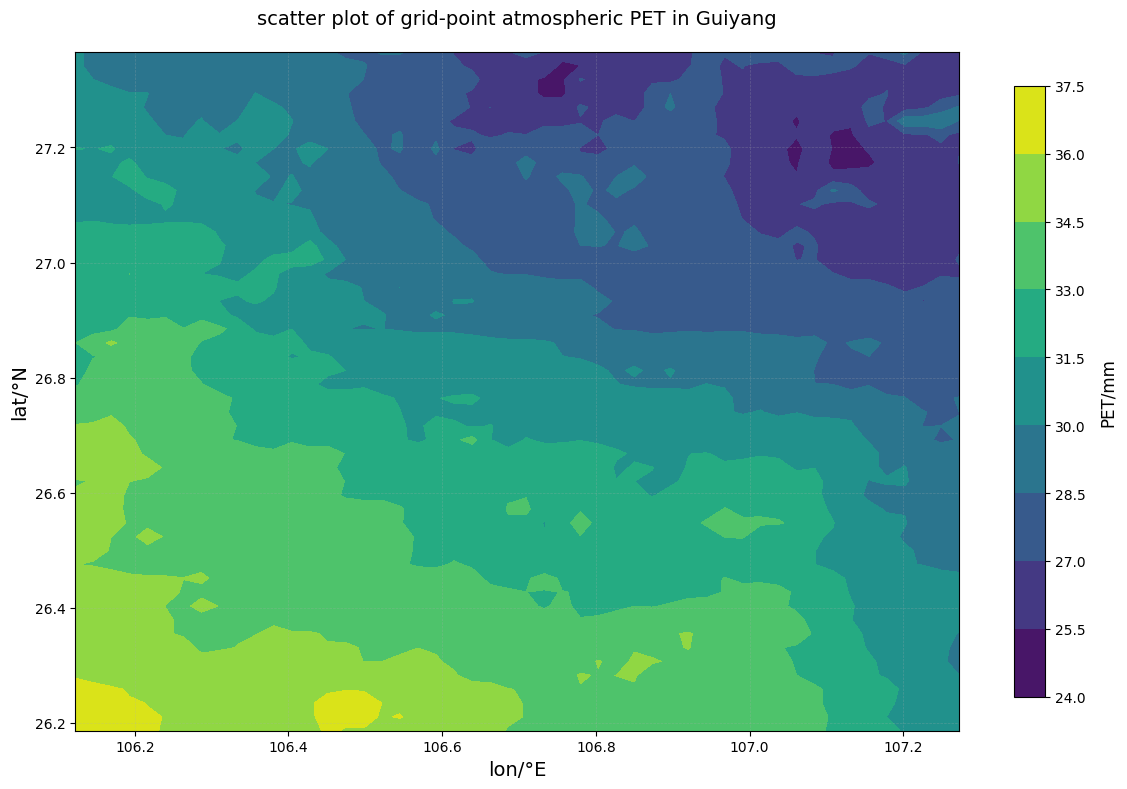

In [14]:
#绘制散点图
fig,ax=plt.subplots(figsize=(12, 8))
ax.set_title("scatter plot of grid-point atmospheric PET in Guiyang", fontsize=14, pad=20)
mesh=ax.contourf(lon_grid,lat_grid,pres_grid,cmap="viridis",shading="auto")
cbar = plt.colorbar(mesh, ax=ax, shrink=0.9)  # shrink调整色条长度，适配图表
cbar.set_label("PET/mm", fontsize=12, labelpad=10) 
cbar.ax.tick_params(labelsize=10) 
ax.set_xlabel("lon/°E", fontsize=14)
ax.set_ylabel("lat/°N", fontsize=14) 
ax.tick_params(axis="both", labelsize=10)
ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)
plt.tight_layout()  # 自动调整布局，避免标签重叠
plt.show()

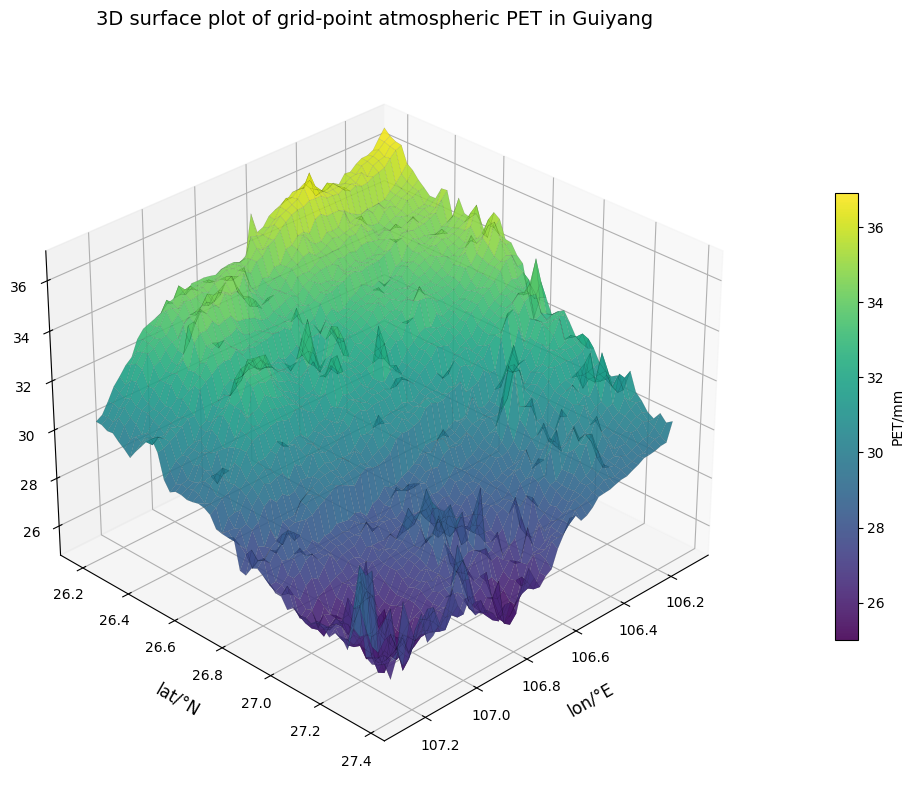

In [15]:
# 绘制气象数据3D曲面/网格图 
import warnings
warnings.filterwarnings("ignore")
fig2 = plt.figure(figsize=(10, 8))
ax2 = fig2.add_subplot(111, projection="3d")
norm = plt.Normalize(vmin=pres_grid.min(), vmax=pres_grid.max())
cmap = plt.cm.viridis
ax2.set_title("3D surface plot of grid-point atmospheric PET in Guiyang", fontsize=14, pad=20)
surf=ax2.plot_surface(lon_grid,lat_grid,pres_grid,cmap=cmap,norm=norm,rstride=1,cstride=1,alpha=0.9,shade=False )
ax2.plot_wireframe(lon_grid, lat_grid, pres_grid,color="k", linewidth=0.2, alpha=0.3)
ax2.set_xlabel("lon/°E", fontsize=12, labelpad=10)
ax2.set_ylabel("lat/°N", fontsize=12, labelpad=10)
ax2.set_zlabel("PET/mm", fontsize=12, labelpad=10)
cbar2 = fig2.colorbar(surf,ax=ax2, shrink=0.6, pad=0.1)
cbar2.set_label("PET/mm", fontsize=10)
ax2.view_init(elev=30, azim=45)
plt.tight_layout()
plt.show()

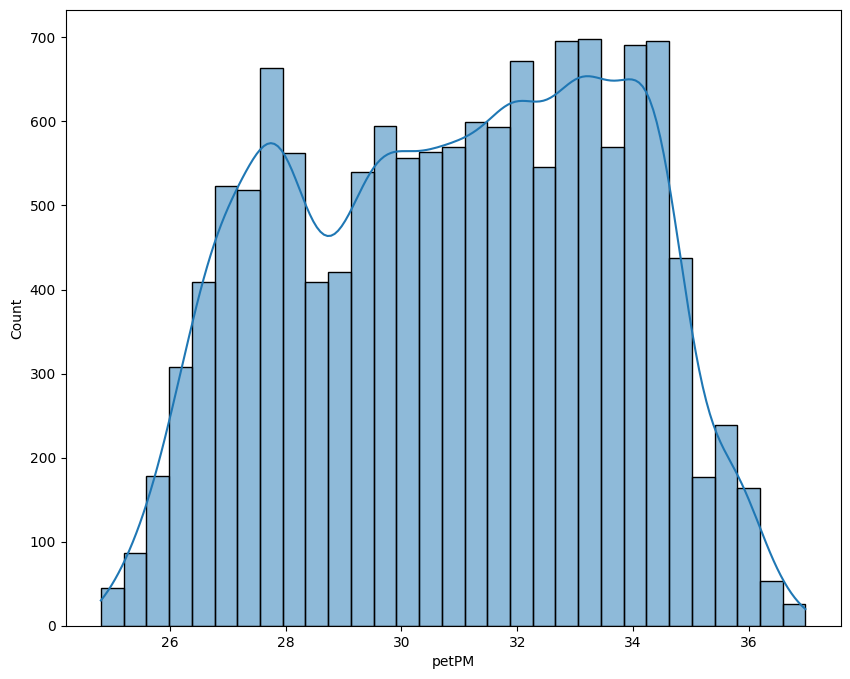

气压数据正态检验结果统计量为:4360.087890625，P值为:0.0


In [16]:
#查看气压分布
import seaborn as sns
from scipy.stats import normaltest
df_guiyang_pressure=df_guiyang.loc[:,'petPM']
plt.figure(figsize=(10, 8))
sns.histplot(df_guiyang_pressure,kde=True)
plt.show()
stats,p_value=normaltest(df_guiyang_pressure)
print(f'气压数据正态检验结果统计量为:{stats}，P值为:{p_value}')

In [17]:
#气压数据分布不满足正态分布，故取中位数作为气压代表值
Pressure=df_guiyang_pressure.median()
Pressure

np.float32(31.057056)